<a href="https://colab.research.google.com/github/ridhimapandey117/Python-Course-YT/blob/master/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import numpy as np

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
from google.colab import files
uploaded = files.upload()
import io
import pandas as pd
for filename, filecontent in uploaded.items():
  print(f'Uploaded file: {filename}, size: {len(filecontent)} bytes')
  if filename.endswith('.csv'):
    train = pd.read_csv(io.BytesIO(filecontent))

Saving titanic_train.csv to titanic_train (2).csv
Uploaded file: titanic_train (2).csv, size: 60302 bytes


In [64]:
from google.colab import files
uploaded = files.upload()
import io
import pandas as pd
for filename, filecontent in uploaded.items():
  print(f'Uploaded file: {filename}, size: {len(filecontent)} bytes')
  if filename.endswith('.csv'):
    test = pd.read_csv(io.BytesIO(filecontent))

Saving titanic_test.csv to titanic_test (1).csv
Uploaded file: titanic_test (1).csv, size: 28210 bytes


In [65]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [66]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


<Axes: >

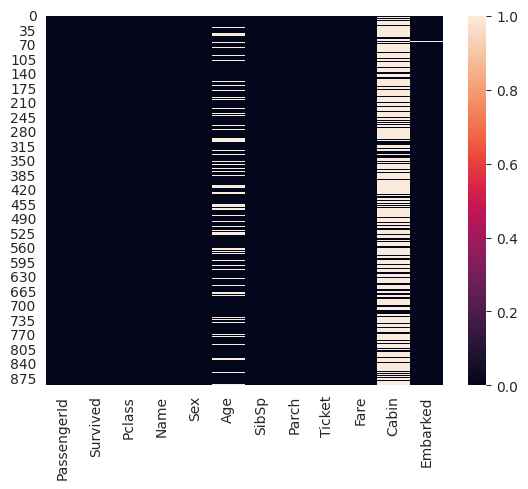

In [67]:
sns.heatmap(train.isnull())

<Axes: xlabel='Survived', ylabel='count'>

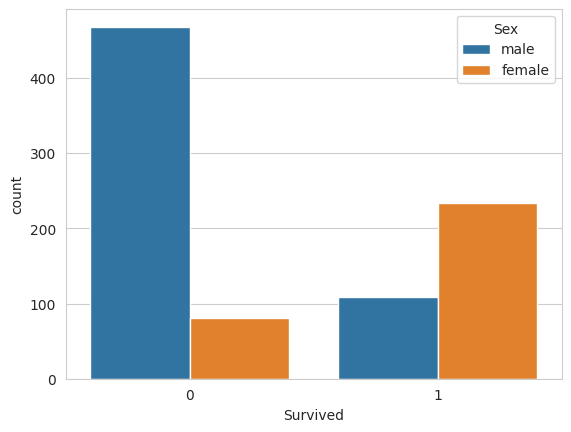

In [68]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train)

/tmp/ipykernel_3240/2989141076.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='Age'>

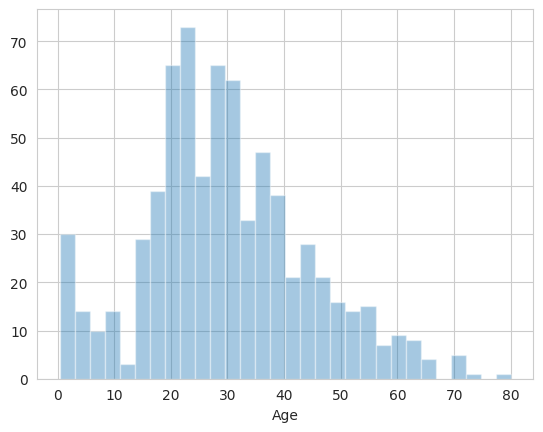

In [69]:
sns.distplot(train['Age'].dropna(), kde=False,bins=30)

<Axes: xlabel='SibSp', ylabel='count'>

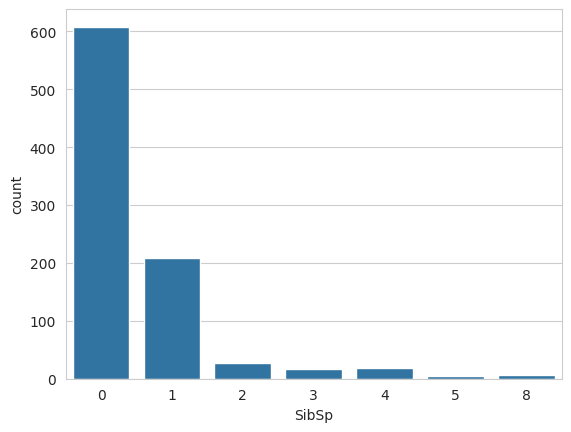

In [70]:
sns.countplot(x='SibSp', data=train)

<Axes: >

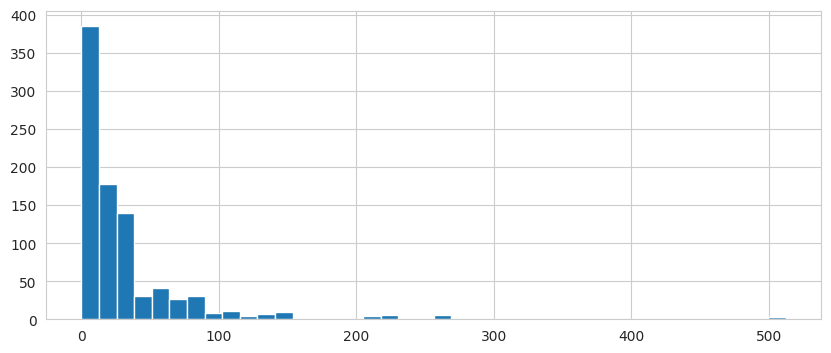

In [71]:
train['Fare'].hist(bins=40,figsize=(10,4))

In [72]:
import cufflinks as cf
cf.go_offline()
train['Fare'].iplot(kind='hist', bins=30)
#SUpposed to make graph inreractive so you can see the specific numbers but I GUESS not

ValueError: 
    Invalid value of type 'builtins.str' received for the 'color' property of histogram.marker
        Received value: 'rgba(255, 153, 51, np.float64(1.0))'

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color:
            aliceblue, antiquewhite, aqua, aquamarine, azure,
            beige, bisque, black, blanchedalmond, blue,
            blueviolet, brown, burlywood, cadetblue,
            chartreuse, chocolate, coral, cornflowerblue,
            cornsilk, crimson, cyan, darkblue, darkcyan,
            darkgoldenrod, darkgray, darkgrey, darkgreen,
            darkkhaki, darkmagenta, darkolivegreen, darkorange,
            darkorchid, darkred, darksalmon, darkseagreen,
            darkslateblue, darkslategray, darkslategrey,
            darkturquoise

<Axes: xlabel='Pclass', ylabel='Age'>

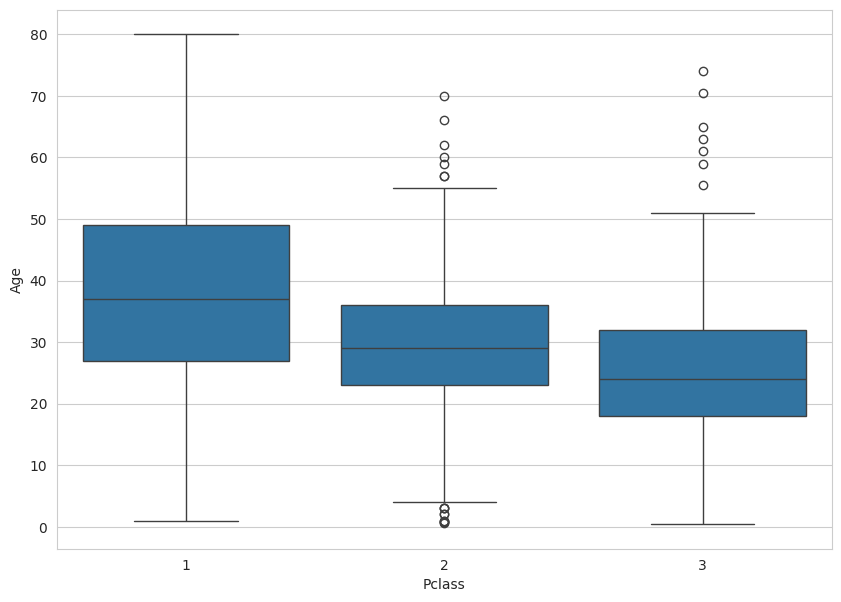

In [73]:
#IMputation: Filling missing values with the average of all the values
plt.figure(figsize=(10,7))
sns.boxplot(x='Pclass',y='Age',data=train)

#As we move from 3rd class to 2nd class and so on, the age of the average passengers tends to get older

In [74]:
#Function will be called to replace NaN values for age
def impute_age(cols):
  Age = cols[0]
  Pclass = cols[1]
  if pd.isnull(Age):
    if Pclass == 1:
      return 37
    elif Pclass == 2:
      return 29
    else:
      return 24
  else:
    return Age

In [75]:
train['Age'] = train[['Age', 'Pclass']].apply(impute_age,axis=1)

/tmp/ipykernel_3240/3017876266.py:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3240/3017876266.py:4: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



<Axes: >

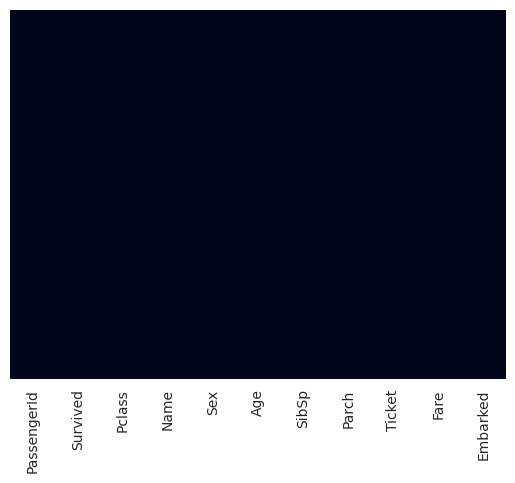

In [78]:
sns.heatmap(train.isnull(), yticklabels=False,cbar=False)

In [77]:
#How to delete a column
train.drop('Cabin', axis=1, inplace=True)
train.dropna(inplace=True)

#Dummy Variable

In [79]:
sex = pd.get_dummies(train['Sex'],drop_first = True)
#we need to drop the female category since having False in one category is a perfect predictor for the other, which will bring up more issues with prediction

In [81]:
embark = pd.get_dummies(train['Embarked'], drop_first=True)
train = pd.concat([train,sex,embark], axis=1)
train.head(2)
train.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)

In [82]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


In [83]:
x = train.drop('Survived', axis=1)
y = train['Survived']

In [86]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=101)

In [87]:
from sklearn.linear_model import LogisticRegression

In [88]:
logmodel = LogisticRegression()
logmodel.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

In [89]:
predictions = logmodel.predict(x_test)

In [91]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86       163
           1       0.84      0.64      0.73       104

    accuracy                           0.81       267
   macro avg       0.82      0.78      0.79       267
weighted avg       0.82      0.81      0.81       267

